RITHESH P

24BAD098


**SCENARIO 1 – ASSOCIATION RULE MINING USING APRIORI ALGORITHM**

Problem Statement
Identify frequent itemsets and generate association rules from transactional data using the Apriori algorithm.

Dataset (Kaggle – Public)
Market Basket Dataset / Grocery Dataset
Example: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset
(Any transactional dataset can be used)

Target Variable: Association rules (frequent item relationships)
Input Feature:
• Transaction ID
• Items purchased

IN-LAB TASKS
1.	Import required Python libraries (Pandas, mlxtend, etc.)
2.	Load transactional dataset
3.	Perform data preprocessing (convert to one-hot encoding format)
4.	Generate frequent itemsets using Apriori algorithm
5.	Set minimum support threshold
6.	Generate association rules
7.	Filter rules using confidence and lift
8.	Interpret rules

Evaluation Metrics
• Support
• Confidence
• Lift

Analysis Tasks
• Observe effect of support threshold on itemsets
• Identify strong association rules
• Compare rules with different confidence levels
• Analyze real-world meaning of rules





Visualization
• Bar chart of frequent itemsets
• Network graph of association rules
• Support vs confidence plots


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
print(sys.executable)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

C:\Users\Rithesh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [3]:
df = pd.read_csv(r"C:\Users\Rithesh\Downloads\archive (7)\Groceries_dataset.csv")


In [4]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [5]:
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

In [6]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dataset Dimensions: {df_encoded.shape}")
print(df_encoded.head())

Dataset Dimensions: (14963, 167)
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisk

In [7]:
min_support = 0.001
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

filtered_rules = rules[rules['confidence'] > 0.05].sort_values(by='lift', ascending=False)

print(f"Total rules found: {len(rules)}")
print(f"Rules after filtering: {len(filtered_rules)}")

Total rules found: 240
Rules after filtering: 94


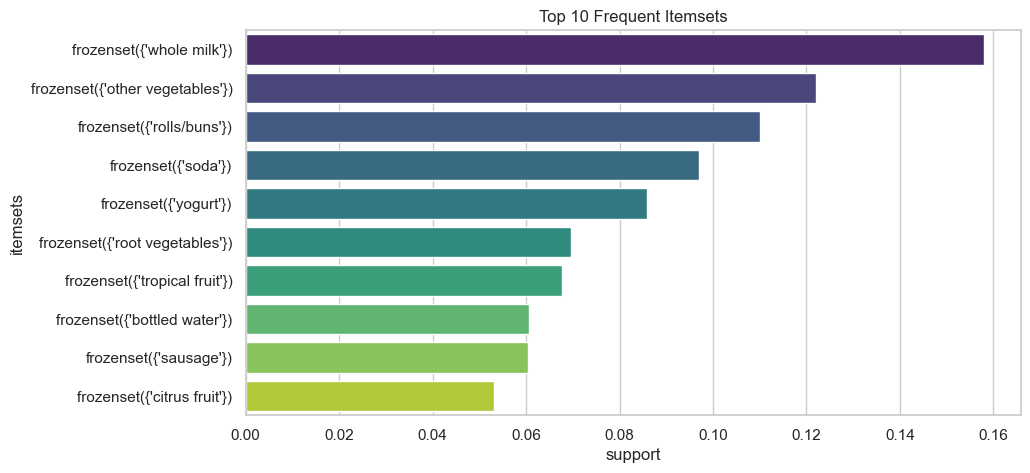

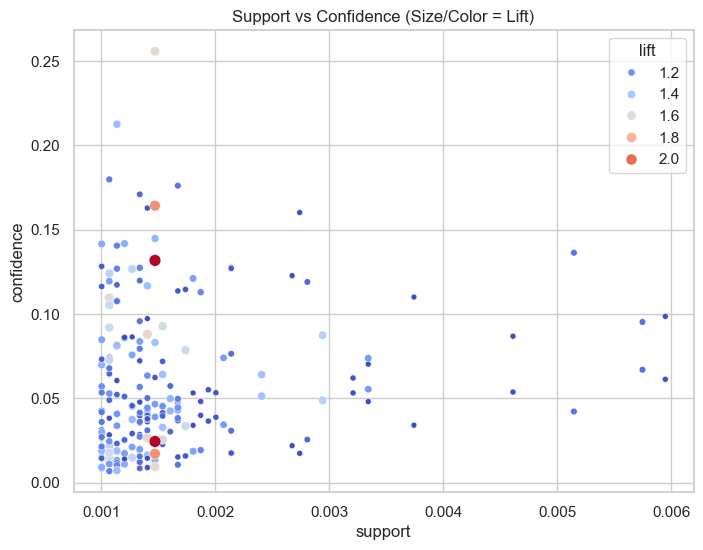

In [8]:
plt.figure(figsize=(10, 5))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
sns.barplot(x='support', y='itemsets', data=top_itemsets, palette='viridis')
plt.title('Top 10 Frequent Itemsets')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence', size='lift', data=rules, hue='lift', palette='coolwarm')
plt.title('Support vs Confidence (Size/Color = Lift)')
plt.grid(True)
plt.show()

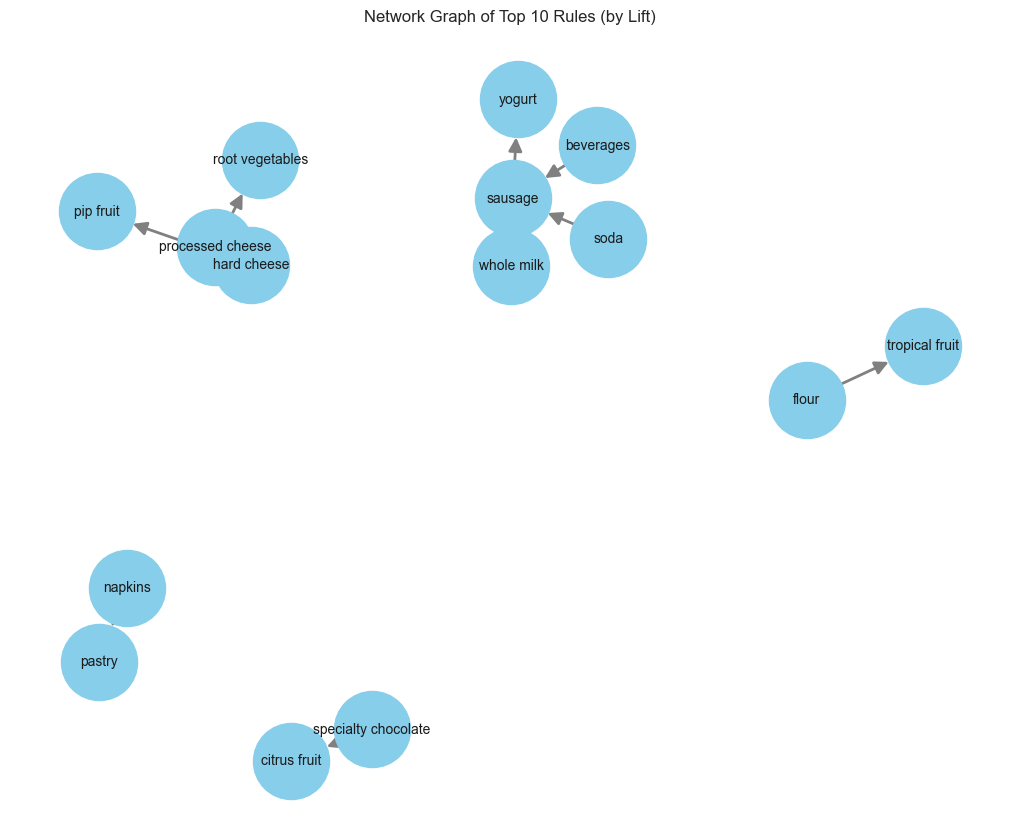

In [9]:
import networkx as nx

def plot_network(rules_df, num_rules=10):
    G = nx.DiGraph()
    subset = rules_df.head(num_rules)

    for i, row in subset.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        G.add_edge(ant, con, weight=row['lift'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000,
            edge_color='gray', font_size=10, width=2, arrowsize=20)
    plt.title(f'Network Graph of Top {num_rules} Rules (by Lift)')
    plt.show()

plot_network(filtered_rules)

**SCENARIO 2 – DIMENSIONALITY REDUCTION USING PCA**

Problem Statement
Reduce high-dimensional data into lower dimensions while preserving maximum variance using PCA.

Dataset (Same / Alternative Dataset)
Any dataset with multiple numerical features
Example: Iris Dataset / Wine Dataset

Target Variable: Principal components (reduced feature set)
Input Features
• Numerical features (e.g., measurements, attributes)

IN-LAB TASKS
1.	Load dataset
2.	Perform data preprocessing (handling missing values, scaling)
3.	Standardize features
4.	Apply Principal Component Analysis (PCA)
5.	Compute principal components
6.	Determine explained variance ratio
7.	Reduce dimensions (e.g., 2D or 3D)
8.	Visualize transformed data

Evaluation Metrics
• Explained Variance Ratio
• Cumulative Variance

Analysis Tasks
• Analyze variance captured by each component
• Decide optimal number of components
• Compare original vs reduced data
• Observe effect on visualization

Visualization
• Scree plot (variance vs components)
• 2D/3D scatter plot of principal components
• Cumulative variance graph


In [10]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [11]:
wine_data = load_wine(as_frame=True)
df = wine_data.frame
X = wine_data.data
y = wine_data.target

print(f"Original Dataset Shape: {X.shape} (13 features!)")

Original Dataset Shape: (178, 13) (13 features!)


In [12]:
if X.isnull().sum().sum() > 0:
    X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [13]:
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

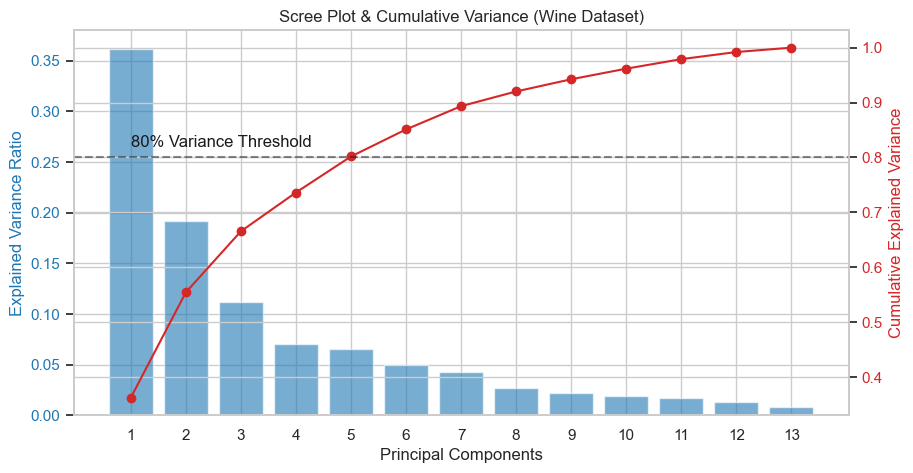

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(range(1, len(explained_variance) + 1), explained_variance,
               alpha=0.6, color='tab:blue', label='Individual Explained Variance')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Explained Variance Ratio', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
line = ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
                marker='o', linestyle='-', color='tab:red', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.axhline(y=0.80, color='k', linestyle='--', alpha=0.5)
ax2.text(1, 0.82, '80% Variance Threshold', color='k')

plt.title('Scree Plot & Cumulative Variance (Wine Dataset)')
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

In [15]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("\nDIMENSION REDUCTION RESULTS")
print(f"Reduced Dataset Shape: {X_pca_2d.shape}")
print(f"Variance captured by PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Variance captured by PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance captured in 2D: {np.sum(pca_2d.explained_variance_ratio_):.4f}\n")


DIMENSION REDUCTION RESULTS
Reduced Dataset Shape: (178, 2)
Variance captured by PC1: 0.3620
Variance captured by PC2: 0.1921
Total variance captured in 2D: 0.5541



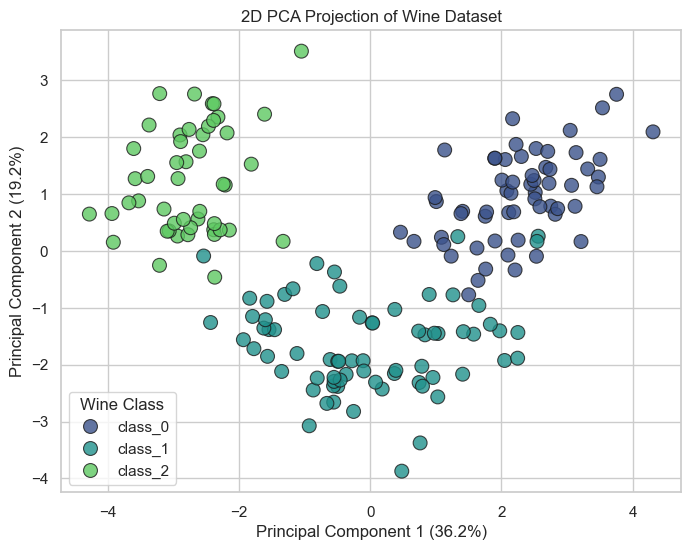

In [16]:
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=wine_data.target_names[y],
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='k'
)
plt.title('2D PCA Projection of Wine Dataset')
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Wine Class')
plt.show()